# NB03 — Build OLS from Scratch (Pure Python)

> **The best way to understand a formula is to code it yourself, step by step.**

---

## The main ideas are:

1. Compute means of x and y
2. Use the slope formula: b1 = Cov / Var
3. Use the intercept formula: b0 = y_bar - b1 * x_bar
4. Compute residuals, SSR, MSE, RMSE, R²
5. Compute standard errors, t-statistics (for NB05 preview)


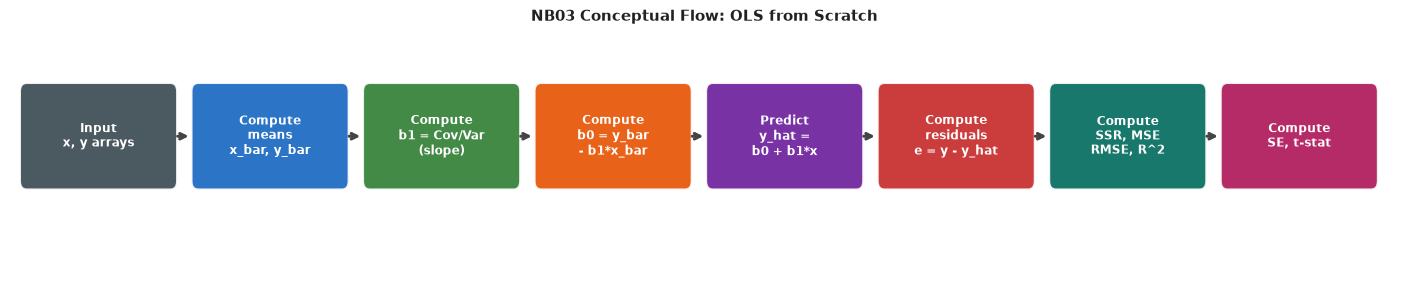

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

def flow_diagram(steps, title, colors=None, notes=None, figsize=(14, 2.8)):
    """Draw a horizontal flow diagram.  steps = list of strings."""
    n = len(steps)
    default_colors = [
        '#1565C0','#2E7D32','#E65100','#6A1B9A',
        '#00695C','#AD1457','#37474F','#4E342E',
        '#0277BD','#558B2F',
    ]
    colors = (colors or default_colors[:n]) + default_colors
    notes  = notes or [''] * n

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.3, n * 3.1)
    ax.set_ylim(-1.2, 2.4)
    ax.axis('off')

    bw, bh = 2.6, 1.3
    for i, (step, color, note) in enumerate(zip(steps, colors, notes)):
        x = i * 3.1
        box = FancyBboxPatch((x, 0.2), bw, bh,
                             boxstyle="round,pad=0.12",
                             facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.90)
        ax.add_patch(box)
        ax.text(x + bw/2, 0.2 + bh/2, step,
                ha='center', va='center', fontsize=8.5,
                color='white', fontweight='bold', multialignment='center')
        if note:
            ax.text(x + bw/2, 0.02, note,
                    ha='center', va='top', fontsize=7, color='#555', style='italic')
        if i < n - 1:
            ax.annotate('',
                xy=(x + bw + 0.38, 0.2 + bh/2),
                xytext=(x + bw + 0.08, 0.2 + bh/2),
                arrowprops=dict(arrowstyle='->', color='#444', lw=2.2))

    ax.set_title(title, fontsize=11, fontweight='bold', pad=6, color='#222')
    plt.tight_layout(pad=0.4)
    plt.show()

flow_diagram(
    steps=[
        'Input\nx, y arrays',
        'Compute\nmeans\nx_bar, y_bar',
        'Compute\nb1 = Cov/Var\n(slope)',
        'Compute\nb0 = y_bar\n- b1*x_bar',
        'Predict\ny_hat =\nb0 + b1*x',
        'Compute\nresiduals\ne = y - y_hat',
        'Compute\nSSR, MSE\nRMSE, R^2',
        'Compute\nSE, t-stat',
    ],
    title='NB03 Conceptual Flow: OLS from Scratch',
    colors=['#37474F','#1565C0','#2E7D32','#E65100','#6A1B9A','#C62828','#00695C','#AD1457'],
)


In [2]:
class OLSRegression:
    """
    Full OLS simple linear regression built from scratch.
    Every formula is coded explicitly — no numpy linalg, no sklearn.
    """

    def __init__(self):
        self.b0 = self.b1 = None

    # ── 1. Fit ────────────────────────────────────────────────────────────────
    def fit(self, X, y):
        n = len(X)
        assert n >= 2,          "Need at least 2 data points"
        assert len(y) == n,     "X and y must have the same length"

        x_bar = sum(X) / n
        y_bar = sum(y) / n

        # Slope: b1 = Cov(x,y) / Var(x)
        cov_xy = sum((X[i]-x_bar)*(y[i]-y_bar) for i in range(n))
        var_x  = sum((X[i]-x_bar)**2              for i in range(n))

        if var_x == 0:
            raise ValueError("All X values identical — cannot fit a line.")

        self.b1   = cov_xy / var_x
        self.b0   = y_bar - self.b1 * x_bar
        self._n   = n
        self._X   = X
        self._y   = y
        return self

    # ── 2. Predict ────────────────────────────────────────────────────────────
    def predict(self, X):
        return [self.b0 + self.b1 * xi for xi in X]

    # ── 3. Residuals ──────────────────────────────────────────────────────────
    def residuals(self, X=None, y=None):
        X = X or self._X;  y = y or self._y
        yhat = self.predict(X)
        return [y[i] - yhat[i] for i in range(len(y))]

    # ── 4. Error metrics ──────────────────────────────────────────────────────
    def ssr(self,   X=None, y=None): return sum(r**2 for r in self.residuals(X,y))
    def mse(self,   X=None, y=None): return self.ssr(X,y) / len(y or self._y)
    def rmse(self,  X=None, y=None): return self.mse(X,y)**0.5

    def r_squared(self, X=None, y=None):
        y  = y or self._y
        ym = sum(y)/len(y)
        ss_tot = sum((yi-ym)**2 for yi in y)
        if ss_tot == 0: return float('nan')
        return 1 - self.ssr(X,y) / ss_tot

    # ── 5. Standard errors (needed for t-tests) ────────────────────────────────
    def se_of_coefficients(self):
        """
        sigma^2 = SSR / (n-2)   <- unbiased: divides by (n-2) NOT n
        SE(b1)  = sqrt(sigma^2 / sum(x - x_bar)^2)
        SE(b0)  = sqrt(sigma^2 * (1/n + x_bar^2 / sum(x-x_bar)^2))
        """
        n, X, y = self._n, self._X, self._y
        sigma2  = self.ssr() / (n - 2)
        x_bar   = sum(X)/n
        sxx     = sum((xi-x_bar)**2 for xi in X)
        se_b1   = (sigma2 / sxx)**0.5
        se_b0   = (sigma2 * (1/n + x_bar**2/sxx))**0.5
        return se_b0, se_b1

    # ── 6. Summary ────────────────────────────────────────────────────────────
    def summary(self, X=None, y=None):
        X = X or self._X;  y = y or self._y
        se_b0, se_b1 = self.se_of_coefficients()
        t_b0 = self.b0 / se_b0
        t_b1 = self.b1 / se_b1
        r2   = self.r_squared(X, y)
        w = 60
        print("=" * w)
        print(f"  OLS Regression Summary")
        print("=" * w)
        print(f"  {'':12} {'Coef':>10}  {'SE':>10}  {'t-stat':>10}")
        print(f"  {'-'*47}")
        print(f"  {'b0 (intercept)':12} {self.b0:>10.4f}  {se_b0:>10.4f}  {t_b0:>10.4f}")
        print(f"  {'b1 (slope)':12}     {self.b1:>10.4f}  {se_b1:>10.4f}  {t_b1:>10.4f}")
        print("=" * w)
        print(f"  R^2  = {r2:.6f}   ({r2*100:.2f}% of variance explained)")
        print(f"  SSR  = {self.ssr():.4f}")
        print(f"  RMSE = {self.rmse():.4f}")
        print(f"  n    = {self._n}")


  OLS Regression Summary
                     Coef          SE      t-stat
  -----------------------------------------------
  b0 (intercept)    32.0000      1.0553     30.3234
  b1 (slope)           6.3636      0.1701     37.4166
  R^2  = 0.994318   (99.43% of variance explained)
  SSR  = 19.0909
  RMSE = 1.3817
  n    = 10


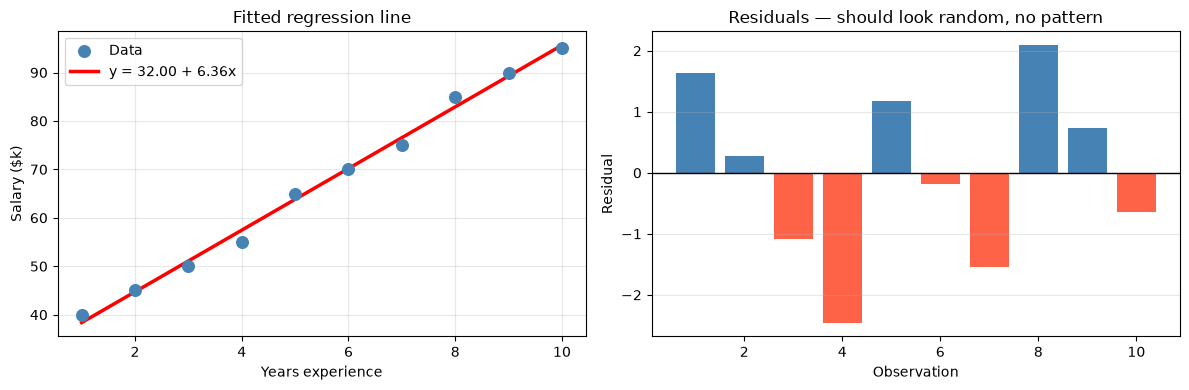

Residuals sum: 2.1316282072803006e-14


In [3]:
# -- Run it on our salary dataset --
X = [1,2,3,4,5,6,7,8,9,10]
y = [40,45,50,55,65,70,75,85,90,95]

model = OLSRegression().fit(X, y)
model.summary()

import matplotlib.pyplot as plt
import numpy as np

y_hat = model.predict(X)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fit
axes[0].scatter(X, y, s=70, color='steelblue', zorder=3, label='Data')
axes[0].plot(X, y_hat, 'r-', linewidth=2.5, label=f'y = {model.b0:.2f} + {model.b1:.2f}x')
axes[0].set_xlabel('Years experience'); axes[0].set_ylabel('Salary ($k)')
axes[0].set_title('Fitted regression line'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Residuals
resid = model.residuals()
axes[1].bar(range(1,11), resid, color=['steelblue' if r>0 else 'tomato' for r in resid])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Observation'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals — should look random, no pattern')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()
print("Residuals sum:", sum(resid))   # always exactly 0 for OLS


In [4]:
# Cross-check against sklearn
from sklearn.linear_model import LinearRegression as SkLR
import numpy as np

X_arr = np.array(X).reshape(-1,1)
sk = SkLR().fit(X_arr, np.array(y))
print(f"Scratch:  b0={model.b0:.8f}  b1={model.b1:.8f}")
print(f"sklearn:  b0={sk.intercept_:.8f}  b1={sk.coef_[0]:.8f}")
print(f"Match: {np.allclose([model.b0,model.b1],[sk.intercept_,sk.coef_[0]])}")


Scratch:  b0=32.00000000  b1=6.36363636
sklearn:  b0=32.00000000  b1=6.36363636
Match: True


## Key Takeaways

| Step | Code | Why |
|------|------|-----|
| Slope | Cov(x,y)/Var(x) | How much x and y co-vary per unit of x spread |
| Intercept | y_bar - b1*x_bar | Anchors line through the mean point |
| Residuals sum | Always = 0 | OLS guarantees this by construction |
| sigma^2 = SSR/(n-2) | NOT n | We estimated 2 parameters, losing 2 degrees of freedom |

**Next: NB04 — what R^2 really measures, with SS decomposition.**
